# 4. Exploratory Data Analysis

## 4.1 Descriptive and Distribution Analysis


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset produced by Task 3
cleaned_data_path = "../data/patient_data_cleaned.csv"
df_clean = pd.read_csv(cleaned_data_path)

print("Cleaned dataset shape:", df_clean.shape)

Cleaned dataset shape: (278701, 40)


In [2]:
# Select important numerical variables for descriptive analysis
summary_columns = [
    "age",
    "bmi",
    "glucose",
    "sleep_hours",
    "systolic_bp",
    "diastolic_bp",
    "heart_rate",
    "hdl",
    "ldl"
]

# Display descriptive statistics for the selected variables
print(df_clean[summary_columns].describe())

# Calculate skew to examine the shape of each distribution
skew_results = (
    df_clean[summary_columns]
    .skew()
    .round(2)
)

print("\nSkew:")
print(skew_results)

# Display the heart disease target proportions
print("\nHeart disease target proportions:")
print(
    df_clean["heart_disease_target"]
    .value_counts(normalize=True)
)

                 age            bmi        glucose    sleep_hours  \
count  278701.000000  278701.000000  278701.000000  278701.000000   
mean       49.710381      27.492328     135.267784       6.954743   
std        21.682385       7.068966      38.503495       1.432179   
min         2.000000      10.010000      70.000000       4.000000   
25%        32.000000      22.010000     100.000000       6.196679   
50%        50.000000      27.320000     137.000000       6.975185   
75%        68.000000      32.700000     160.000000       7.700000   
max        89.000000      95.690000     300.000000      10.000000   

         systolic_bp   diastolic_bp     heart_rate            hdl  \
count  278701.000000  278701.000000  278701.000000  278701.000000   
mean      134.408557      89.476008      74.498800      64.606647   
std        20.625881      13.723066      11.449471      16.003633   
min        90.000000      60.000000      50.000000      30.000000   
25%       125.000000      83.0000

Age is close to symmetric, while BMI and glucose have small positive skew values of 0.31 and 0.38. Their wider upper ranges are examined further in the distribution plots.

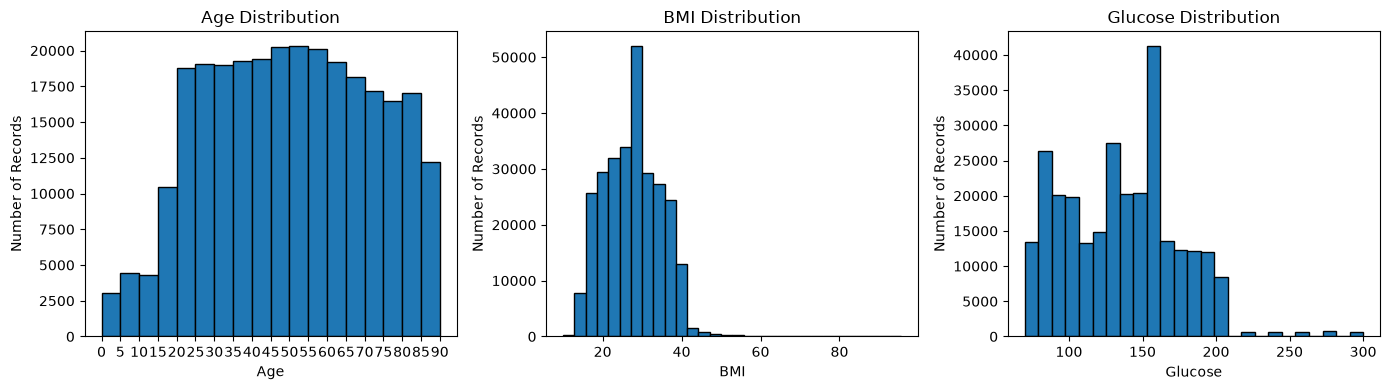

In [3]:
# Create clearer histograms for age, BMI and glucose
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot age with wider 5-year bins
age_bins = range(0, 95, 5)
axes[0].hist(
    df_clean["age"].dropna(),
    bins=age_bins,
    edgecolor="black"
)
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Number of Records")
axes[0].set_title("Age Distribution")
axes[0].set_xticks(age_bins)

# Plot BMI
axes[1].hist(
    df_clean["bmi"].dropna(),
    bins=30,
    edgecolor="black"
)
axes[1].set_xlabel("BMI")
axes[1].set_ylabel("Number of Records")
axes[1].set_title("BMI Distribution")

# Plot glucose
axes[2].hist(
    df_clean["glucose"].dropna(),
    bins=25,
    edgecolor="black"
)
axes[2].set_xlabel("Glucose")
axes[2].set_ylabel("Number of Records")
axes[2].set_title("Glucose Distribution")

plt.tight_layout()
plt.show()

The age distribution is broad, while BMI and glucose show longer upper tails. These shapes are consistent with the positive skew values in the descriptive summary.

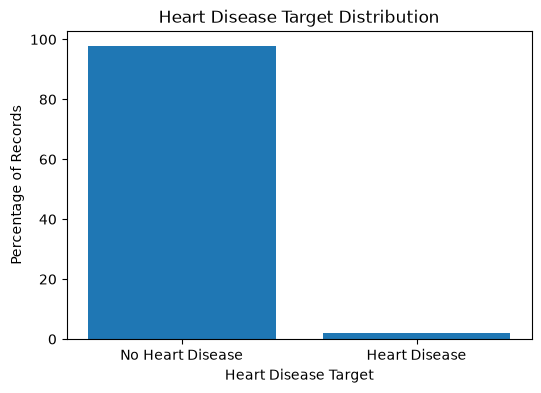

heart_disease_target
False    97.89
True      2.11
Name: proportion, dtype: float64


In [4]:
# Calculate the percentage of records in each heart disease target class
target_percentage = (
    df_clean["heart_disease_target"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

# Plot the heart disease target distribution
plt.figure(figsize=(6, 4))

plt.bar(
    ["No Heart Disease", "Heart Disease"],
    target_percentage.values
)

plt.xlabel("Heart Disease Target")
plt.ylabel("Percentage of Records")
plt.title("Heart Disease Target Distribution")

plt.show()

# Display the exact percentages
print(target_percentage.round(2))

The target is highly imbalanced: 2.11% of records are labelled with heart disease and 97.89% are not.

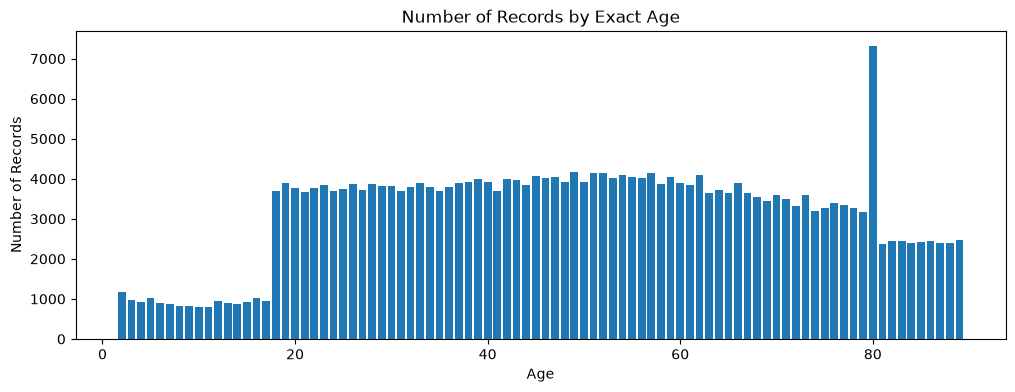

In [5]:
# Count how many records occur at each exact age
age_counts = (
    df_clean["age"]
    .value_counts()
    .sort_index()
)

# Plot the number of records for each age
plt.figure(figsize=(12, 4))

plt.bar(
    age_counts.index,
    age_counts.values
)

plt.xlabel("Age")
plt.ylabel("Number of Records")
plt.title("Number of Records by Exact Age")

plt.show()

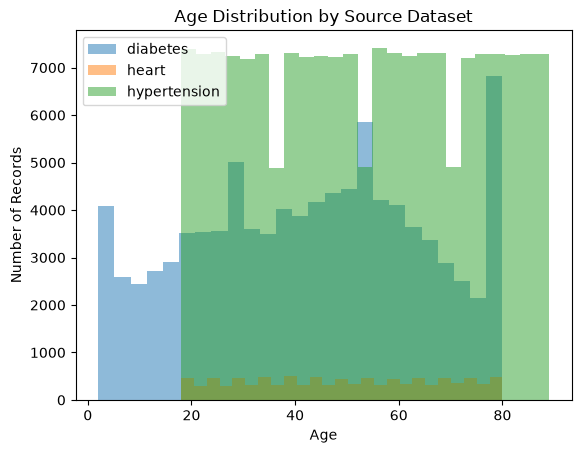

In [6]:
# Compare age distributions across the three source datasets
for source in df_clean["source_dataset"].unique():
    source_data = df_clean[
        df_clean["source_dataset"] == source
    ]

    plt.hist(
        source_data["age"],
        bins=25,
        alpha=0.5,
        label=source
    )

plt.xlabel("Age")
plt.ylabel("Number of Records")
plt.title("Age Distribution by Source Dataset")
plt.legend()

plt.show()

In [7]:
# Check which source datasets contribute to the large age 80 spike
age_80_sources = (
    df_clean.loc[df_clean["age"] == 80, "source_dataset"]
    .value_counts()
)

print("Records at age 80 by source dataset:")
print(age_80_sources)

Records at age 80 by source dataset:
source_dataset
diabetes        4743
hypertension    2425
heart            158
Name: count, dtype: int64


In [8]:
# Compare the number of records near age 80 for each source dataset
age_75_to_80 = (
    df_clean[
        df_clean["age"].between(75, 80)
    ]
    .groupby(
        ["source_dataset", "age"]
    )
    .size()
    .unstack(fill_value=0)
)

print(age_75_to_80)

age               75    76    77    78    79    80
source_dataset                                    
diabetes         704   714   818   663   601  4743
heart            163   176   167   158   165   158
hypertension    2406  2507  2368  2456  2416  2425


The age 80 spike mainly comes from the diabetes source, which contributes 4,743 records at that age. The hypertension counts remain similar from ages 75 to 80, while the heart source contributes far fewer records.

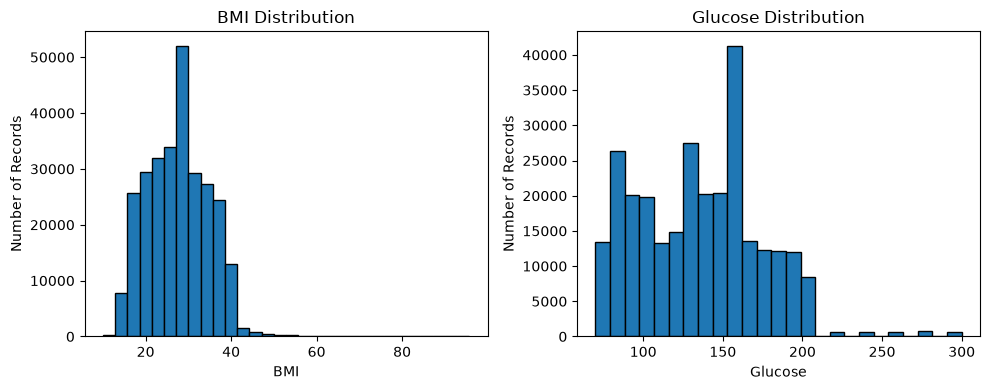

In [9]:
# Create a figure with two histograms: BMI and glucose
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plot the BMI distribution
axes[0].hist(
    df_clean["bmi"].dropna(),
    bins=30,
    edgecolor="black"
)
axes[0].set_xlabel("BMI")
axes[0].set_ylabel("Number of Records")
axes[0].set_title("BMI Distribution")

# Plot the glucose distribution
axes[1].hist(
    df_clean["glucose"].dropna(),
    bins=25,
    edgecolor="black"
)
axes[1].set_xlabel("Glucose")
axes[1].set_ylabel("Number of Records")
axes[1].set_title("Glucose Distribution")

# Improve spacing between the two plots
plt.tight_layout()

plt.show()

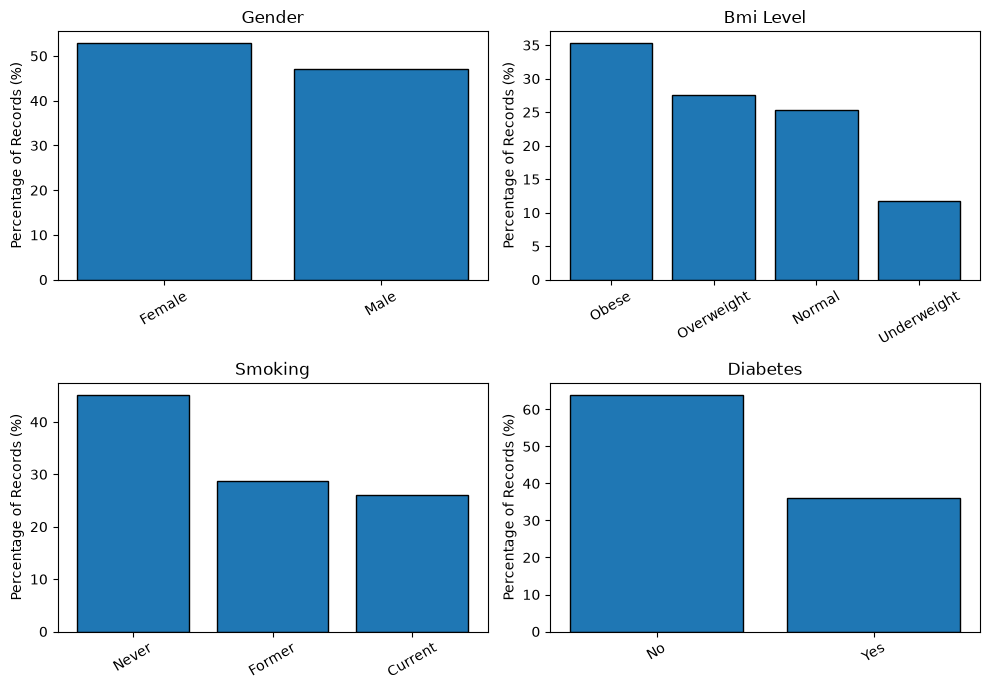

In [10]:
# Select categorical variables to inspect
categorical_columns = [
    "gender",
    "bmi_level",
    "smoking",
    "diabetes"
]

# Create a 2 x 2 figure
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for ax, column in zip(axes.flatten(), categorical_columns):

    # Calculate the percentage of records in each category
    percentages = (
        df_clean[column]
        .value_counts(normalize=True)
        .mul(100)
    )

    # Plot the category percentages
    ax.bar(
        percentages.index.astype(str),
        percentages.values,
        edgecolor="black"
    )

    ax.set_title(column.replace("_", " ").title())
    ax.set_ylabel("Percentage of Records (%)")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

The category percentages are not evenly distributed across every variable, so these differences should be considered when comparing groups in later analysis.